# Rotation and Translation Checker and Visualizer for FK

In [2]:
!pip install numpy matplotlib ipympl


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%matplotlib widget

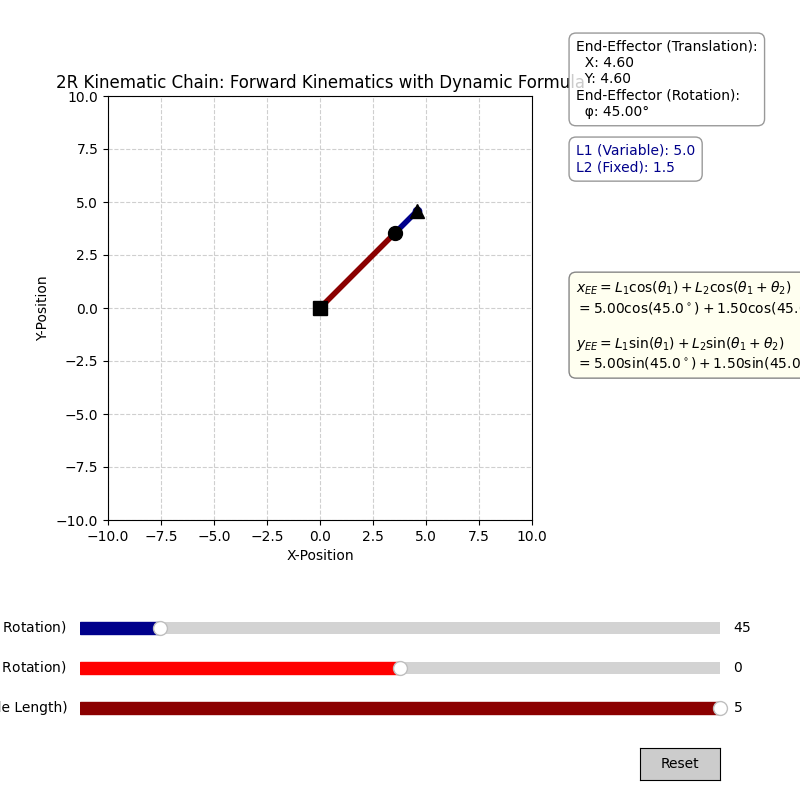

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# --- Configuration ---
L2_FIXED = 1.5
THETA1_INITIAL = 45
THETA2_INITIAL = 0
L1_INITIAL = 5.0

EE_X_POS = 0.0
EE_Y_POS = 0.0

# --- Setup Figure ---
fig, ax = plt.subplots(figsize=(8, 8))
plt.subplots_adjust(left=0.1, bottom=0.35, right=0.7)
ax.set_aspect('equal', adjustable='box')
ax.set_title("2R Kinematic Chain: Forward Kinematics with Dynamic Formula")
ax.set_xlabel("X-Position")
ax.set_ylabel("Y-Position")
ax.grid(True, linestyle='--', alpha=0.6)
max_range = 10.0
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)

line1, = ax.plot([0, 0], [0, 0], 'o-', lw=4, color='darkred', label='Link 1 (Variable)')
line2, = ax.plot([0, 0], [0, 0], 'o-', lw=4, color='darkblue', label='Link 2 (Fixed)')
joint0, = ax.plot(0, 0, 'ks', ms=10, label='Base Joint (0,0)')
joint1, = ax.plot(0, 0, 'ko', ms=10, label='Joint 1')
ee_point, = ax.plot(0, 0, 'k^', ms=10, label='End-Effector (P_EE)')

coord_text = fig.text(0.72, 0.95, '', fontsize=10, verticalalignment='top', horizontalalignment='left',
                      bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8, ec="grey"))
link_length_text = fig.text(0.72, 0.82, '', fontsize=10, verticalalignment='top', horizontalalignment='left', color='darkblue',
                            bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8, ec="grey"))
formula_text = fig.text(0.72, 0.65, '', fontsize=10, verticalalignment='top', horizontalalignment='left',
                       bbox=dict(boxstyle="round,pad=0.5", fc="ivory", alpha=0.95, ec="grey"))

annotation = ax.annotate(
    '', xy=(0, 0), xytext=(20, 20), textcoords='offset points',
    bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.7),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2", color='black'),
    visible=False
)

# --- Forward Kinematics ---
def forward_kinematics(theta1_deg, theta2_deg, l1_var):
    th1 = np.deg2rad(theta1_deg)
    th2 = np.deg2rad(theta2_deg)
    th_ee = th1 + th2
    p1_x = l1_var * np.cos(th1)
    p1_y = l1_var * np.sin(th1)
    pee_x = p1_x + L2_FIXED * np.cos(th_ee)
    pee_y = p1_y + L2_FIXED * np.sin(th_ee)
    phi_deg = theta1_deg + theta2_deg
    return p1_x, p1_y, pee_x, pee_y, phi_deg

# --- Update Plot ---
def update(val):
    global EE_X_POS, EE_Y_POS

    th1_deg = s_theta1.val
    th2_deg = s_theta2.val
    l1 = s_l1.val

    p1_x, p1_y, pee_x, pee_y, phi_deg = forward_kinematics(th1_deg, th2_deg, l1)
    EE_X_POS = pee_x
    EE_Y_POS = pee_y

    # Plot links and joints
    line1.set_data([0, p1_x], [0, p1_y])
    joint1.set_data([p1_x], [p1_y])
    line2.set_data([p1_x, pee_x], [p1_y, pee_y])
    ee_point.set_data([pee_x], [pee_y])

    # Update text with EE coordinates and link lengths
    coord_text.set_text(
        f'End-Effector (Translation):\n'
        f'  X: {pee_x:.2f}\n'
        f'  Y: {pee_y:.2f}\n'
        f'End-Effector (Rotation):\n'
        f'  φ: {phi_deg:.2f}°'
    )
    link_length_text.set_text(
        f'L1 (Variable): {l1:.1f}\n'
        f'L2 (Fixed): {L2_FIXED:.1f}'
    )

    # Dynamic forward kinematics formula display
    formula_text.set_text(
        "$x_{EE} = L_1 \\cos(\\theta_1) + L_2 \\cos(\\theta_1 + \\theta_2)$\n"
        f"$= {l1:.2f} \\cos({th1_deg:.1f}^\\circ) + {L2_FIXED:.2f} \\cos({th1_deg+th2_deg:.1f}^\\circ) = {EE_X_POS:.2f}$\n\n"
        "$y_{EE} = L_1 \\sin(\\theta_1) + L_2 \\sin(\\theta_1 + \\theta_2)$\n"
        f"$= {l1:.2f} \\sin({th1_deg:.1f}^\\circ) + {L2_FIXED:.2f} \\sin({th1_deg+th2_deg:.1f}^\\circ) = {EE_Y_POS:.2f}$"
    )

    fig.canvas.draw_idle()

# --- Hover annotation ---
def on_move(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        if annotation.get_visible():
            annotation.set_visible(False)
            fig.canvas.draw_idle()
        return
    ee_x = EE_X_POS
    ee_y = EE_Y_POS
    dist = np.sqrt((event.xdata - ee_x)**2 + (event.ydata - ee_y)**2)
    threshold = 0.5
    if dist < threshold:
        annotation.xy = (ee_x, ee_y)
        annotation.set_text(f'P_EE:\n(X: {ee_x:.2f}, Y: {ee_y:.2f})')
        if not annotation.get_visible():
            annotation.set_visible(True)
            fig.canvas.draw_idle()
    else:
        if annotation.get_visible():
            annotation.set_visible(False)
            fig.canvas.draw_idle()

# --- Sliders ---
ax_t1 = plt.axes([0.1, 0.20, 0.8, 0.03], facecolor='#f0f0f0')
ax_t2 = plt.axes([0.1, 0.15, 0.8, 0.03], facecolor='#f0f0f0')
ax_l1 = plt.axes([0.1, 0.10, 0.8, 0.03], facecolor='#f0f0f0')

s_theta1 = Slider(ax_t1, '$\\theta_1$ (Base Rotation)', 0, 360, valinit=THETA1_INITIAL, valstep=1, color='darkblue')
s_theta2 = Slider(ax_t2, '$\\theta_2$ (Relative Rotation)', -180, 180, valinit=THETA2_INITIAL, valstep=1, color='red')
s_l1 = Slider(ax_l1, 'L1 (Variable Length)', 1.0, 5.0, valinit=L1_INITIAL, valstep=0.1, color='darkred')

s_theta1.on_changed(update)
s_theta2.on_changed(update)
s_l1.on_changed(update)

# --- Reset Button ---
ax_reset = plt.axes([0.8, 0.025, 0.1, 0.04])
button = Button(ax_reset, 'Reset', color='#cccccc', hovercolor='0.975')
def reset(event): s_theta1.reset(); s_theta2.reset(); s_l1.reset()
button.on_clicked(reset)

fig.canvas.mpl_connect('motion_notify_event', on_move)

update(None)

plt.show()

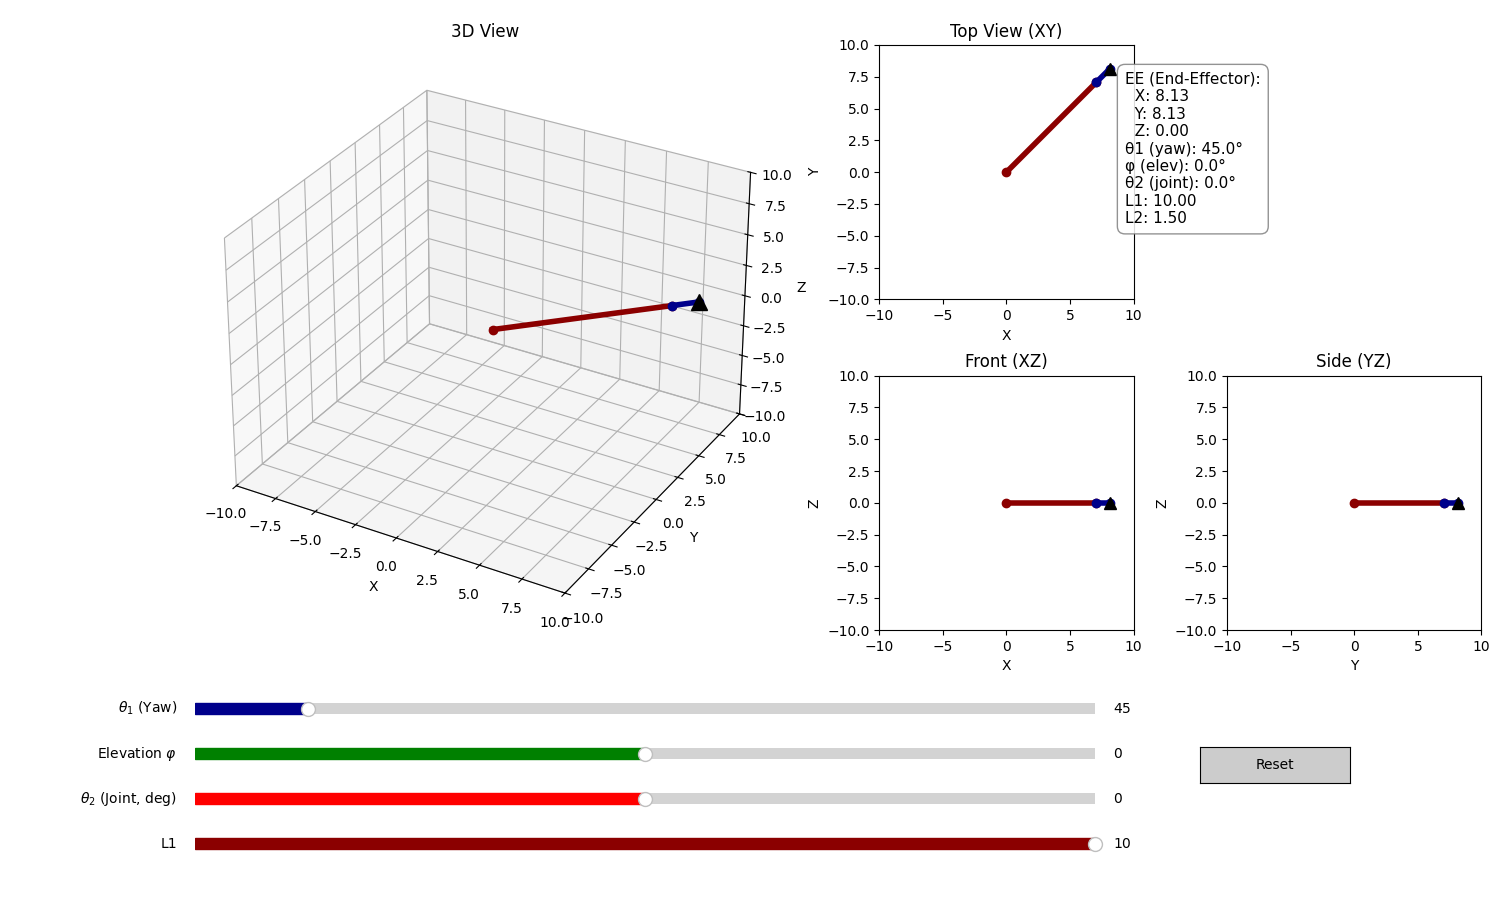

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from mpl_toolkits.mplot3d import Axes3D

def rot_z(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0, 0],
                     [s,  c, 0, 0],
                     [0,  0, 1, 0],
                     [0,  0, 0, 1]])

def rot_x(phi):
    c, s = np.cos(phi), np.sin(phi)
    return np.array([[1, 0,  0, 0],
                     [0, c, -s, 0],
                     [0, s,  c, 0],
                     [0, 0,  0, 1]])

def trans_x(L):
    return np.array([[1, 0, 0, L],
                     [0, 1, 0, 0],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1]])

# --- Configuration ---
L2_FIXED = 1.5
THETA1_INITIAL = 45
ELEV_INITIAL = 0
THETA2_INITIAL = 0
L1_INITIAL = 10.0

# Figure and axes
fig = plt.figure(figsize=(15, 9))
plt.subplots_adjust(left=0.12, bottom=0.30, right=0.99, top=0.95, wspace=0.33, hspace=0.30)
ax3d = plt.subplot2grid((2,4), (0,0), colspan=2, rowspan=2, projection='3d')
axXY = plt.subplot2grid((2,4), (0,2))
axXZ = plt.subplot2grid((2,4), (1,2))
axYZ = plt.subplot2grid((2,4), (1,3))
max_range = 10.0
for ax2d in [axXY, axXZ, axYZ]:
    ax2d.set_xlim(-max_range, max_range)
    ax2d.set_ylim(-max_range, max_range)
ax3d.set_xlim(-max_range, max_range)
ax3d.set_ylim(-max_range, max_range)
ax3d.set_zlim(-max_range, max_range)
ax3d.set_title("3D View")
axXY.set_title("Top View (XY)")
axXZ.set_title("Front (XZ)")
axYZ.set_title("Side (YZ)")
axXY.set_xlabel("X"); axXY.set_ylabel("Y")
axXZ.set_xlabel("X"); axXZ.set_ylabel("Z")
axYZ.set_xlabel("Y"); axYZ.set_ylabel("Z")
ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")

line1_3d, = ax3d.plot([0,0],[0,0],[0,0],'o-',lw=4,color='darkred')
line2_3d, = ax3d.plot([0,0],[0,0],[0,0],'o-',lw=4,color='darkblue')
ee_point3d, = ax3d.plot([0],[0],[0],'k^',ms=12)

line1_XY, = axXY.plot([0,0],[0,0],'o-',lw=4,color='darkred')
line2_XY, = axXY.plot([0,0],[0,0],'o-',lw=4,color='darkblue')
ee_pointXY, = axXY.plot([0],[0],'k^',ms=9)

line1_XZ, = axXZ.plot([0,0],[0,0],'o-',lw=4,color='darkred')
line2_XZ, = axXZ.plot([0,0],[0,0],'o-',lw=4,color='darkblue')
ee_pointXZ, = axXZ.plot([0],[0],'k^',ms=9)

line1_YZ, = axYZ.plot([0,0],[0,0],'o-',lw=4,color='darkred')
line2_YZ, = axYZ.plot([0,0],[0,0],'o-',lw=4,color='darkblue')
ee_pointYZ, = axYZ.plot([0],[0],'k^',ms=9)

coord_text = fig.text(0.75, 0.92, '', fontsize=11, verticalalignment='top', horizontalalignment='left',
                     bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.85, ec="gray"))

def forward_kinematics(theta1_deg, elev_deg, theta2_deg, l1):
    # Convert
    th1 = np.deg2rad(theta1_deg)
    elev = np.deg2rad(elev_deg)
    th2 = np.deg2rad(theta2_deg)

    # Homogeneous chain: T_origin * R_x(elev) * R_z(theta1) * T_x(l1)
    T1 = rot_x(elev) @ rot_z(th1) @ trans_x(l1)
    p1 = T1 @ np.array([0,0,0,1])
    # Second link is rotated θ2 about Z at p1
    T2 = rot_z(th2) @ trans_x(L2_FIXED)
    p2 = T1 @ T2 @ np.array([0,0,0,1])

    # Return joint XYZ
    return (0, p1[0], p2[0]), (0, p1[1], p2[1]), (0, p1[2], p2[2]), (p2[0], p2[1], p2[2])

def update(val):
    th1_deg, elev_deg, th2_deg, l1 = s_theta1.val, s_elev.val, s_theta2.val, s_l1.val
    Xs, Ys, Zs, EE = forward_kinematics(th1_deg, elev_deg, th2_deg, l1)
    p1_x, p1_y, p1_z = Xs[1], Ys[1], Zs[1]
    pee_x, pee_y, pee_z = EE

    line1_3d.set_data(Xs[:2], Ys[:2])
    line1_3d.set_3d_properties(Zs[:2])
    line2_3d.set_data(Xs[1:], Ys[1:])
    line2_3d.set_3d_properties(Zs[1:])
    ee_point3d.set_data([pee_x], [pee_y])
    ee_point3d.set_3d_properties([pee_z])

    line1_XY.set_data(Xs[:2], Ys[:2]); line2_XY.set_data(Xs[1:], Ys[1:])
    ee_pointXY.set_data([pee_x],[pee_y]); axXY.set_aspect('equal', adjustable='box')
    line1_XZ.set_data(Xs[:2], Zs[:2]); line2_XZ.set_data(Xs[1:], Zs[1:])
    ee_pointXZ.set_data([pee_x],[pee_z]); axXZ.set_aspect('equal', adjustable='box')
    line1_YZ.set_data(Ys[:2], Zs[:2]); line2_YZ.set_data(Ys[1:], Zs[1:])
    ee_pointYZ.set_data([pee_y],[pee_z]); axYZ.set_aspect('equal', adjustable='box')

    coord_text.set_text(
        f'EE (End-Effector):\n'
        f'  X: {pee_x:.2f}\n'
        f'  Y: {pee_y:.2f}\n'
        f'  Z: {pee_z:.2f}\n'
        f'θ1 (yaw): {th1_deg:.1f}°\n'
        f'φ (elev): {elev_deg:.1f}°\n'
        f'θ2 (joint): {th2_deg:.1f}°\n'
        f'L1: {l1:.2f}\nL2: {L2_FIXED:.2f}'
    )
    fig.canvas.draw_idle()

ax_t1 = plt.axes([0.13, 0.20, 0.6, 0.025], facecolor='#e5e5e5')
ax_phi = plt.axes([0.13, 0.15, 0.6, 0.025], facecolor='#e5e5e5')
ax_t2 = plt.axes([0.13, 0.10, 0.6, 0.025], facecolor='#e5e5e5')
ax_l1 = plt.axes([0.13, 0.05, 0.6, 0.025], facecolor='#e5e5e5')

s_theta1 = Slider(ax_t1, '$\\theta_1$ (Yaw)', 0, 360, valinit=THETA1_INITIAL, valstep=1, color='darkblue')
s_elev = Slider(ax_phi, 'Elevation $\\varphi$', -90, 90, valinit=ELEV_INITIAL, valstep=1, color='green')
s_theta2 = Slider(ax_t2, '$\\theta_2$ (Joint, deg)', -180, 180, valinit=THETA2_INITIAL, valstep=1, color='red')
s_l1 = Slider(ax_l1, 'L1', 1.0, 10.0, valinit=L1_INITIAL, valstep=0.1, color='darkred')
s_theta1.on_changed(update)
s_elev.on_changed(update)
s_theta2.on_changed(update)
s_l1.on_changed(update)

ax_reset = plt.axes([0.80, 0.13, 0.1, 0.04])
button = Button(ax_reset, 'Reset', color='#cccccc', hovercolor='0.975')
def reset(event):
    s_theta1.reset(); s_elev.reset(); s_theta2.reset(); s_l1.reset()
button.on_clicked(reset)

update(None)
plt.show()
